<a href="https://colab.research.google.com/github/bahadirberkerdemir/SOFTITO_YapayZeka/blob/main/Python_Giris/22-09-2026_wineQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import statsmodels.api as sm

sns.set_style("whitegrid")
sns.set_context("poster")
import warnings
warnings.filterwarnings("ignore")
#

### Load `winequality-red.csv` and display its structure

In [23]:
red_wine_df = pd.read_csv('/content/winequality-red.csv', sep=';')
display(red_wine_df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Content of `winequality.names`

This file typically contains metadata, attribute information, or a description of the dataset, helping to understand the meaning of each column in the CSV file.

In [24]:
with open('/content/winequality.names', 'r') as f:
    names_content = f.read()
print(names_content)

Citation Request:
  This dataset is public available for research. The details are described in [Cortez et al., 2009]. 
  Please include this citation if you plan to use this database:

  P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. 
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.

  Available at: [@Elsevier] http://dx.doi.org/10.1016/j.dss.2009.05.016
                [Pre-press (pdf)] http://www3.dsi.uminho.pt/pcortez/winequality09.pdf
                [bib] http://www3.dsi.uminho.pt/pcortez/dss09.bib

1. Title: Wine Quality 

2. Sources
   Created by: Paulo Cortez (Univ. Minho), Antonio Cerdeira, Fernando Almeida, Telmo Matos and Jose Reis (CVRVV) @ 2009
   
3. Past Usage:

  P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. 
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 016

### Load `winequality-white.csv` and combine with red wine data

In [25]:
# Load the white wine dataset
white_wine_df = pd.read_csv('/content/winequality-white.csv', sep=';')

# Add a 'type' column to distinguish red and white wines
red_wine_df['type'] = 'red'
white_wine_df['type'] = 'white'

# Combine the two dataframes
df = pd.concat([red_wine_df, white_wine_df], ignore_index=True)

display(df.head())
display(df.tail())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white


In [26]:
print("Veri Seti Boyutu:",df.shape)
df.info()

Veri Seti Boyutu: (6497, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


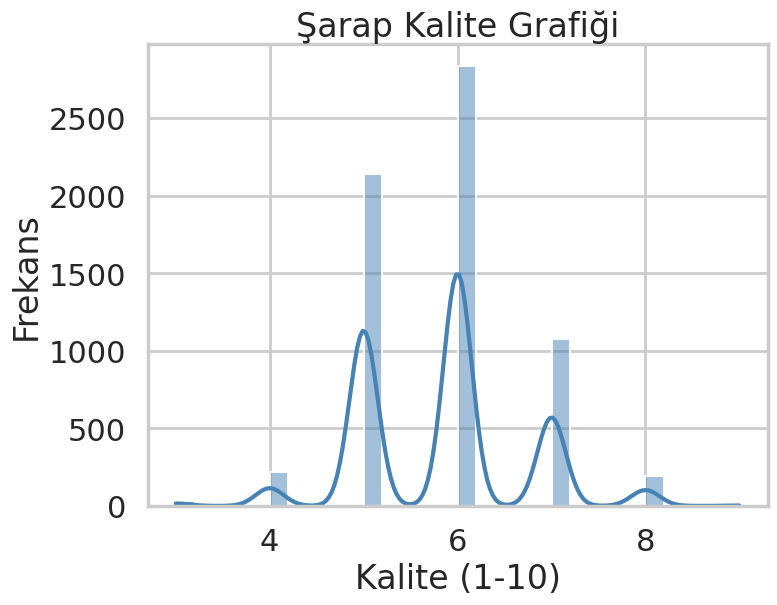

In [28]:
plt.figure(figsize=(8,6))
sns.histplot(df["quality"],bins=30,kde= True, color ="steelblue")

plt.title("Şarap Kalite Grafiği")
plt.xlabel("Kalite (1-10)")
plt.ylabel("Frekans")

plt.show()

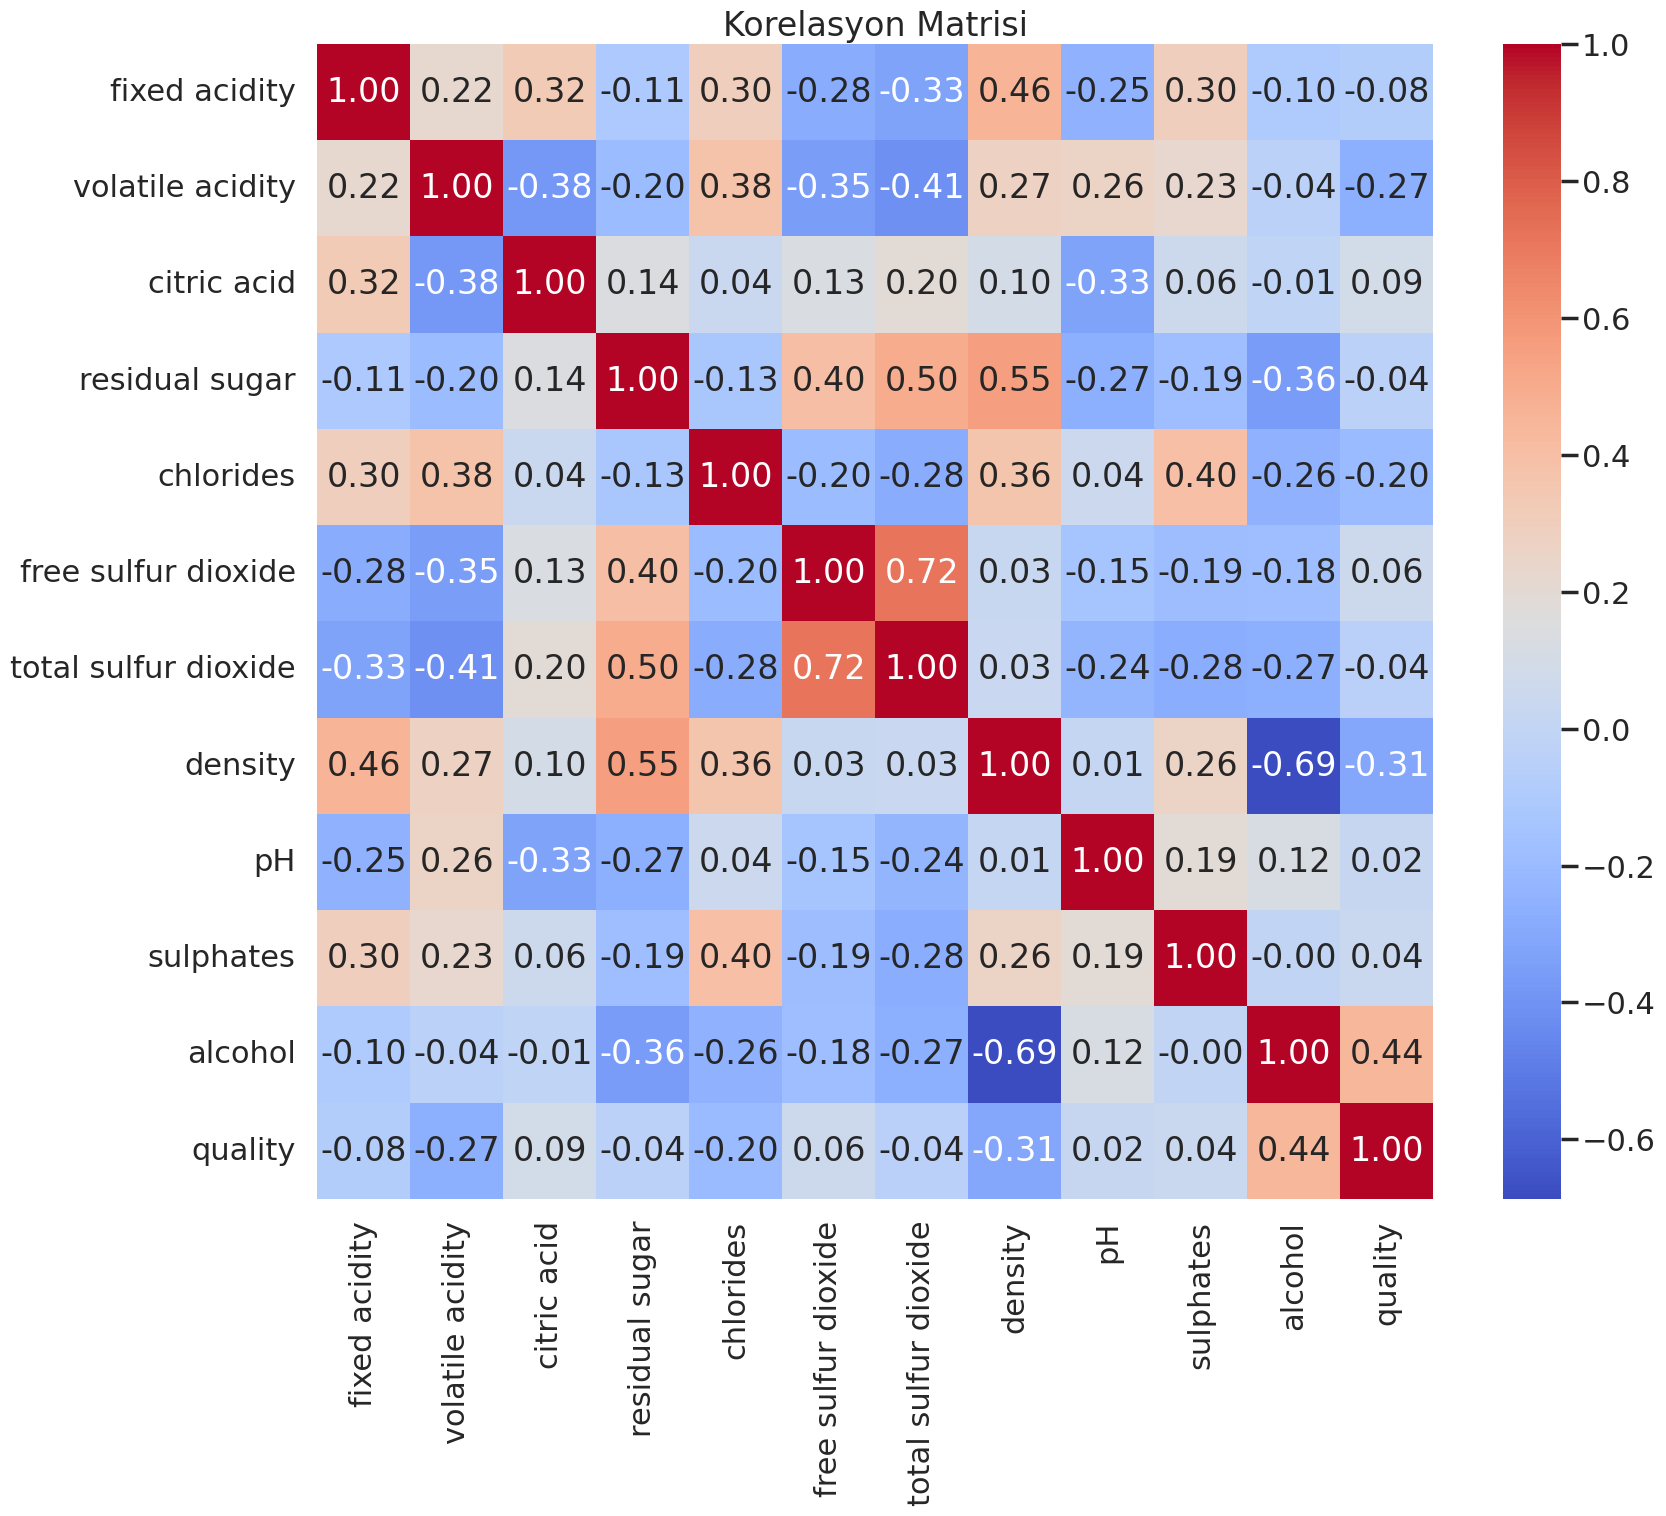

In [29]:
numeric_cols = df.select_dtypes(include=[np.number]) # numeric_cols = df.drop(columns=["X"])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(18, 15
                    ))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")
plt.show()

In [30]:
# Create dummy variables for the 'type' column.
# Using drop_first=True prevents multicollinearity by creating N-1 dummy variables for N categories.
# For 'red' and 'white', it will create one column, e.g., 'type_white'.
df_encoded = pd.get_dummies(df, columns=["type"], drop_first=True)

In [31]:
display(df_encoded.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,False


In [32]:
y = df_encoded["quality"]
X = df_encoded.drop(columns=['quality', 'density', 'free sulfur dioxide'])

display(X.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,pH,sulphates,alcohol,type_white
0,7.4,0.70,0.00,1.9,0.076,34.0,3.51,0.56,9.4,False
1,7.8,0.88,0.00,2.6,0.098,67.0,3.20,0.68,9.8,False
2,7.8,0.76,0.04,2.3,0.092,54.0,3.26,0.65,9.8,False
3,11.2,0.28,0.56,1.9,0.075,60.0,3.16,0.58,9.8,False
4,7.4,0.70,0.00,1.9,0.076,34.0,3.51,0.56,9.4,False


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
model = LinearRegression()
model.fit(X_train, y_train)
model_pred = model.predict(X_test)

In [35]:
r2_multi = r2_score(y_test, model_pred)
print("R2 Değeri:", r2_multi)
mae_multi = mean_absolute_error(y_test, model_pred)
print("MAE Değeri:", mae_multi)
mse_multi = mean_squared_error(y_test, model_pred)
print("MSE Değeri:", mse_multi)

R2 Değeri: 0.26519102439133246
MAE Değeri: 0.5691368612384071
MSE Değeri: 0.5426907775456241


In [36]:
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     211.1
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:38:12   Log-Likelihood:                -5802.0
No. Observations:                5197   AIC:                         1.163e+04
Df Residuals:                    5186   BIC:                         1.170e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.2110      0.348      6.349      0.000       1.528       2.894
fixed acidity           -0.0020      0.012     -0.173      0.863      -0.025       0.021
volatile acidity        -1.7020      0.091    -18.688      0.000      -1.880      -1.523
citric acid             -0.1390      0.090     -1.538      0.124      -0.316       0.038
residual sugar           0.0257      0.003      9.833      0.000       0.021       0.031
chlorides               -0.8361      0.379     -2.208      0.027      -1.578      -0.094
total sulfur dioxide    -0.0004      0.000     -1.227      0.220      -0.001       0.000
pH                       0.1132      0.081      1.396      0.163      -0.046       0.272
sulphates                0.6088      0.084      7.273      0.000       0.445       0.773
alcohol                  0.3478      0.010     33.462      0.000       0.327       0.368
type_white              -0.1958      0.054     -3.633      0.000      -0.301      -0.090
==============================================================================
Omnibus:                      101.599   Durbin-Watson:                   2.052
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              205.756
Skew:                           0.074   Prob(JB):                     2.09e-45
Kurtosis:                       3.964   Cond. No.                     5.21e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
model = LinearRegression()
model.fit(X_train, y_train)
model_pred = model.predict(X_test)

In [39]:
r2_multi = r2_score(y_test, model_pred)
print("R2 Değeri:", r2_multi)
mae_multi = mean_absolute_error(y_test, model_pred)
print("MAE Değeri:", mae_multi)
mse_multi = mean_squared_error(y_test, model_pred)
print("MSE Değeri:", mse_multi)

R2 Değeri: 0.26519102439133246
MAE Değeri: 0.5691368612384071
MSE Değeri: 0.5426907775456241


In [40]:
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     211.1
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:38:13   Log-Likelihood:                -5802.0
No. Observations:                5197   AIC:                         1.163e+04
Df Residuals:                    5186   BIC:                         1.170e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.2110      0.348      6.349      0.000       1.528       2.894
fixed acidity           -0.0020      0.012     -0.173      0.863      -0.025       0.021
volatile acidity        -1.7020      0.091    -18.688      0.000      -1.880      -1.523
citric acid             -0.1390      0.090     -1.538      0.124      -0.316       0.038
residual sugar           0.0257      0.003      9.833      0.000       0.021       0.031
chlorides               -0.8361      0.379     -2.208      0.027      -1.578      -0.094
total sulfur dioxide    -0.0004      0.000     -1.227      0.220      -0.001       0.000
pH                       0.1132      0.081      1.396      0.163      -0.046       0.272
sulphates                0.6088      0.084      7.273      0.000       0.445       0.773
alcohol                  0.3478      0.010     33.462      0.000       0.327       0.368
type_white              -0.1958      0.054     -3.633      0.000      -0.301      -0.090
==============================================================================
Omnibus:                      101.599   Durbin-Watson:                   2.052
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              205.756
Skew:                           0.074   Prob(JB):                     2.09e-45
Kurtosis:                       3.964   Cond. No.                     5.21e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
model = LinearRegression()
model.fit(X_train, y_train)
model_pred = model.predict(X_test)

In [43]:
r2_multi = r2_score(y_test, model_pred)
print("R2 Değeri:", r2_multi)
mae_multi = mean_absolute_error(y_test, model_pred)
print("MAE Değeri:", mae_multi)
mse_multi = mean_squared_error(y_test, model_pred)
print("MSE Değeri:", mse_multi)

R2 Değeri: 0.26519102439133246
MAE Değeri: 0.5691368612384071
MSE Değeri: 0.5426907775456241


In [44]:
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     211.1
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:38:13   Log-Likelihood:                -5802.0
No. Observations:                5197   AIC:                         1.163e+04
Df Residuals:                    5186   BIC:                         1.170e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.2110      0.348      6.349      0.000       1.528       2.894
fixed acidity           -0.0020      0.012     -0.173      0.863      -0.025       0.021
volatile acidity        -1.7020      0.091    -18.688      0.000      -1.880      -1.523
citric acid             -0.1390      0.090     -1.538      0.124      -0.316       0.038
residual sugar           0.0257      0.003      9.833      0.000       0.021       0.031
chlorides               -0.8361      0.379     -2.208      0.027      -1.578      -0.094
total sulfur dioxide    -0.0004      0.000     -1.227      0.220      -0.001       0.000
pH                       0.1132      0.081      1.396      0.163      -0.046       0.272
sulphates                0.6088      0.084      7.273      0.000       0.445       0.773
alcohol                  0.3478      0.010     33.462      0.000       0.327       0.368
type_white              -0.1958      0.054     -3.633      0.000      -0.301      -0.090
==============================================================================
Omnibus:                      101.599   Durbin-Watson:                   2.052
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              205.756
Skew:                           0.074   Prob(JB):                     2.09e-45
Kurtosis:                       3.964   Cond. No.                     5.21e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [45]:
display(df_encoded.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,False


In [46]:
y= df_encoded["quality"]
X= df_encoded.drop(columns=['quality'])

In [47]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
model=LinearRegression()
model.fit(X_train,y_train)
model_pred =model.predict(X_test)

In [49]:
r2_multi = r2_score(y_test,model_pred)
print("R2 Değeri:",r2_multi)
mae_multi = mean_absolute_error(y_test,model_pred)
print("MAE Değeri:",mae_multi)
mse_multi = mean_squared_error(y_test,model_pred)
print("MSE Değeri:",mse_multi)

R2 Değeri: 0.26715748512627224
MAE Değeri: 0.5644129055666061
MSE Değeri: 0.5412384543695586


In [50]:
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train,X_train_sm).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     187.7
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:38:13   Log-Likelihood:                -5751.8
No. Observations:                5197   AIC:                         1.153e+04
Df Residuals:                    5184   BIC:                         1.161e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  102.6388     15.427      6.653      0.000      72.395     132.882
fixed acidity            0.0921      0.017      5.306      0.000       0.058       0.126
volatile acidity        -1.5088      0.092    -16.349      0.000      -1.690      -1.328
citric acid             -0.0979      0.090     -1.092      0.275      -0.274       0.078
residual sugar           0.0628      0.007      9.615      0.000       0.050       0.076
chlorides               -0.5826      0.377     -1.544      0.123      -1.323       0.157
free sulfur dioxide      0.0060      0.001      6.797      0.000       0.004       0.008
total sulfur dioxide    -0.0016      0.000     -4.430      0.000      -0.002      -0.001
density               -102.0817     15.645     -6.525      0.000    -132.753     -71.410
pH                       0.5276      0.100      5.252      0.000       0.331       0.725
sulphates                0.7630      0.085      8.933      0.000       0.596       0.930
alcohol                  0.2326      0.020     11.795      0.000       0.194       0.271
type_white              -0.3352      0.064     -5.240      0.000      -0.461      -0.210
==============================================================================
Omnibus:                      114.372   Durbin-Watson:                   2.051
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              244.654
Skew:                           0.075   Prob(JB):                     7.48e-54
Kurtosis:                       4.052   Cond. No.                     2.88e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.88e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

2 numaralı uyarıya bakılacak

Text(0, 0.5, 'Tahmin Edilen Değerler')

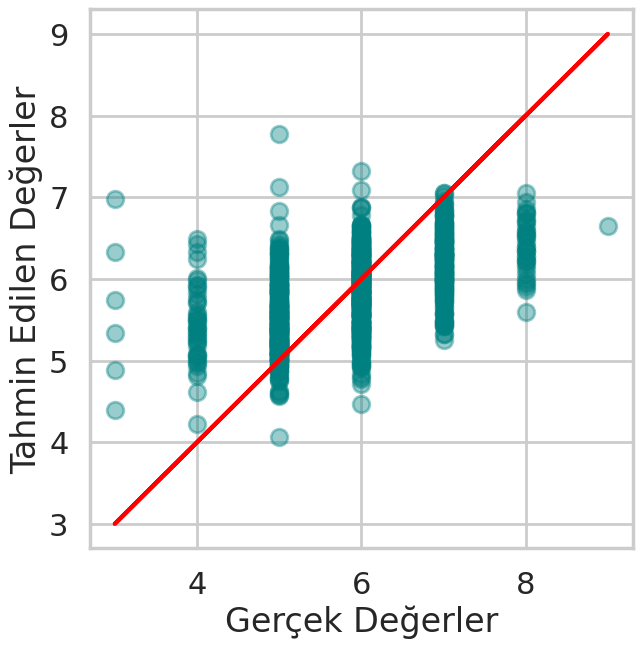

In [51]:
plt.figure(figsize=(7,7))
plt.scatter(y_test,model_pred ,alpha=0.4,color="teal")
plt.plot(y_test,y_test,"r")
plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Edilen Değerler")

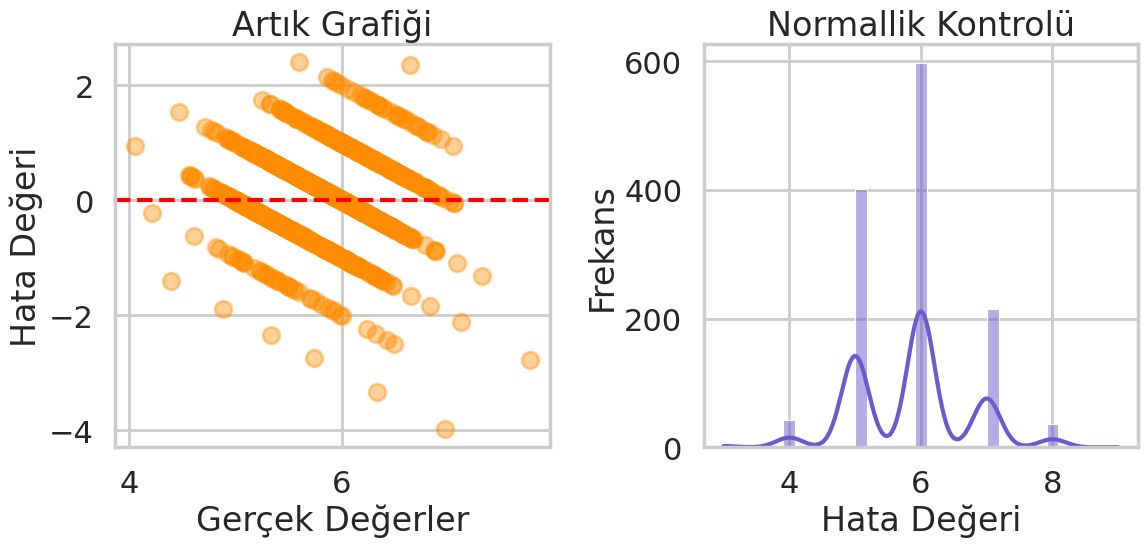

In [52]:
residual =y_test-model_pred
fig, axes = plt.subplots(1,2,figsize=(12,6))
axes[0].scatter(model_pred,residual,alpha=0.4,color="darkorange")
axes[0].axhline(y=0,color="red",linestyle="--")
axes[0].set_xlabel("Gerçek Değerler")
axes[0].set_ylabel("Hata Değeri")
axes[0].set_title("Artık Grafiği")
sns.histplot(y_test,kde=True,ax=axes[1],color="slateblue")
axes[1].set_title("Gerçek Değerler")
axes[1].set_title("Normallik Kontrolü")
axes[1].set_xlabel("Hata Değeri")
axes[1].set_ylabel("Frekans")

plt.tight_layout()
plt.show()

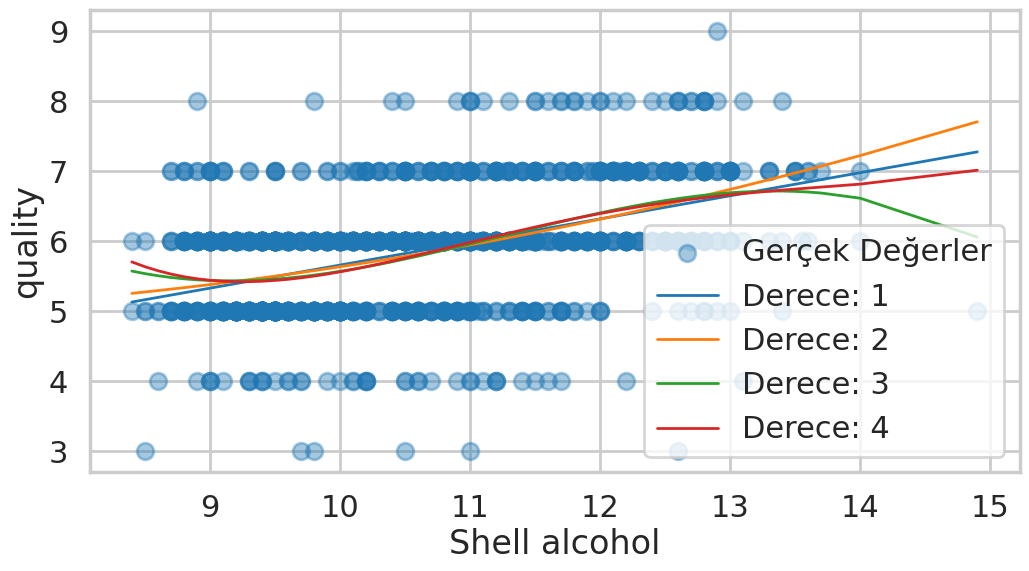

,r2,Rmse
Derece,,
1,0.181585,0.777456
2,0.181517,0.777488
3,0.194533,0.771281
4,0.191945,0.772520


In [53]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degress =[1,2,3,4]

poly_results= {}

plt.figure(figsize=(12,6))
X_one_train =X_train[['alcohol']]
X_one_test =X_test[['alcohol']]
sort_idx =X_one_test['alcohol'].values.argsort()
x_sorted =X_one_test['alcohol'].values[sort_idx]
plt.scatter(X_one_test['alcohol'],y_test,alpha=0.4,color="#1f77b4",label="Gerçek Değerler")
for degree in degress:
    model_poly = make_pipeline(PolynomialFeatures(degree),LinearRegression())
    model_poly.fit(X_one_train,y_train)
    poly_pred = model_poly.predict(X_one_test)
    poly_results[degree]={
        "r2": r2_score(y_test,poly_pred),
        "Rmse" : np.sqrt(mean_squared_error(y_test,poly_pred))
}
    y_line = model_poly.predict(x_sorted.reshape(-1,1))
    plt.plot(x_sorted,y_line,linewidth=2,label=f"Derece: {degree}")
plt.xlabel("Shell alcohol")
plt.ylabel("quality")
plt.legend()
plt.show()

pd.DataFrame(poly_results).T.rename_axis("Derece")


In [54]:
poly_features = PolynomialFeatures(degree=2)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

poly_multi_model =LinearRegression()
poly_multi_model.fit(X_poly_train,y_train)
poly_multi_pred =poly_multi_model.predict(X_poly_test)

r2_score_poly = r2_score(y_test,poly_multi_pred)
print("R2 Değeri:",r2_score_poly)
mae_poly = mean_absolute_error(y_test,poly_multi_pred)
print("MAE Değeri:",mae_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test,poly_multi_pred))
print("RMSE Değeri:",rmse_poly)

R2 Değeri: 0.22714419964029742
MAE Değeri: 0.5450713078803221
RMSE Değeri: 0.7555065427542462


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,accuracy_score,precision_score,
recall_score,f1_score,classification_report,roc_curve,roc_auc_score)

In [56]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
df_encoded = pd.get_dummies(df,columns=categorical_cols,drop_first=True)
bool_cols = df_encoded.select_dtypes(include="bool").columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [57]:
X=df_encoded.drop(columns=["quality"])
y=(df_encoded["quality"] >= 6).astype(int)

In [58]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [59]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)
X_train_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_white
5765,-1.090555,-0.666206,-0.059177,-0.408934,-0.342753,0.257745,0.762110,-1.580817,-0.172375,-1.075166,1.351763,0.579054
4915,-1.090555,-0.968619,0.351975,-0.915325,-0.564537,0.033814,-0.333855,-1.767141,-0.359201,-0.347428,1.267996,0.579054
232,0.968621,0.180552,-0.812955,-0.556631,0.932506,-0.693962,-1.005575,1.087606,0.761757,1.108047,-0.742420,-1.726956
3480,-0.022834,-0.847654,1.996583,2.270719,-0.370476,-0.917893,-0.210117,1.320511,-0.981956,-1.141324,-1.077489,0.579054
4726,0.282229,-0.242827,0.420501,-0.704328,-0.370476,-1.141824,-0.298501,-0.589309,-0.296926,0.777257,0.430323,0.579054


In [60]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [61]:
y_proba =log_reg.predict_proba(X_test_scaled)[:,1]
y_pred =log_reg.predict(X_test_scaled)

results_preview =pd.DataFrame({
    "Gerçek:": y_test.values[:10],
    "Tahmin:": y_pred[:10],
    "Olasılık:": y_proba[:10].round(2)
})

results_preview

,Gerçek:,Tahmin:,Olasılık:
0,0,0,0.16
1,0,1,0.70
2,0,1,0.56
3,1,1,0.61
4,1,1,0.61
5,1,1,0.64
6,0,1,0.71
7,1,1,0.56
8,1,1,0.59
9,1,0,0.25


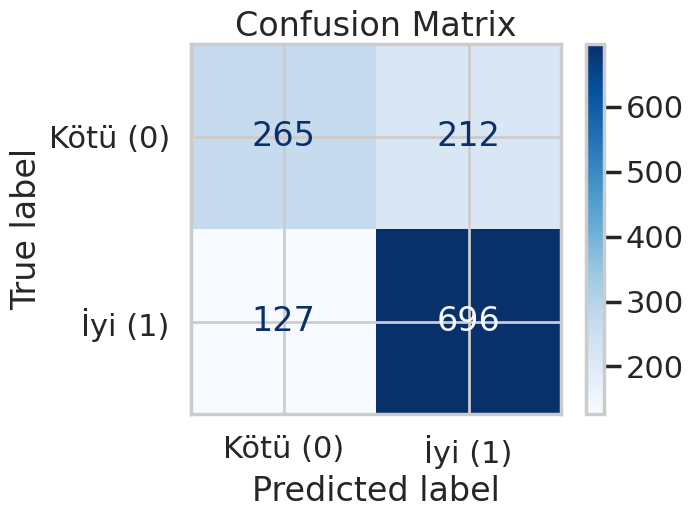

Doğruluk (Accuracy): 0.7392307692307692
Kesinlik (Precision): 0.7665198237885462
Geri Çağırma (Recall): 0.8456865127582017
F1 Skoru (F1-Score): 0.804159445407279

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.68      0.56      0.61       477
           1       0.77      0.85      0.80       823

    accuracy                           0.74      1300
   macro avg       0.72      0.70      0.71      1300
weighted avg       0.73      0.74      0.73      1300



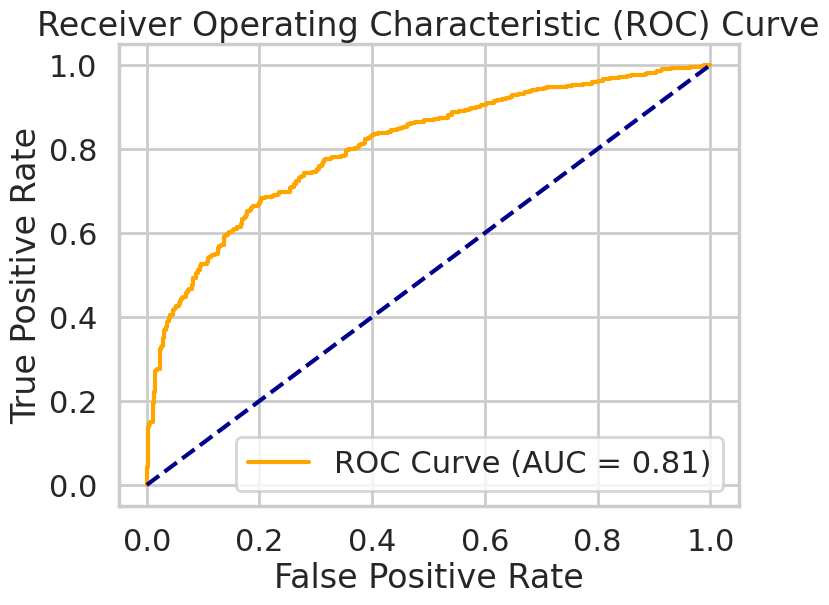

In [62]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Kötü (0)", "İyi (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

print("Doğruluk (Accuracy):", accuracy_score(y_test, y_pred))
print("Kesinlik (Precision):", precision_score(y_test, y_pred))
print("Geri Çağırma (Recall):", recall_score(y_test, y_pred))
print("F1 Skoru (F1-Score):", f1_score(y_test, y_pred))
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label='ROC Curve (AUC = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [63]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)


print(classification_report(y_test,y_pred))

Accuracy: 0.7392307692307692
Precision: 0.7665198237885462
Recall: 0.8456865127582017
F1 Score: 0.804159445407279
              precision    recall  f1-score   support

           0       0.68      0.56      0.61       477
           1       0.77      0.85      0.80       823

    accuracy                           0.74      1300
   macro avg       0.72      0.70      0.71      1300
weighted avg       0.73      0.74      0.73      1300



Random forest deneyeceğim, değişkenlerimizin hedef ile lineer bir ilişkisi olsaydı sonuçlarımız biraz daha iyi  olurdu.

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Random Forest modelini tanımlıyoruz (çekirdek sabiti için random_state ekleyebiliriz)
rf_model = RandomForestClassifier(random_state=42)

# Modeli eğitim verimizle (X_train, y_train) eğitiyoruz
rf_model.fit(X_train, y_train)

# Test verisi üzerinden tahmin yapıyoruz
y_pred = rf_model.predict(X_test)

# Performans sonuçlarını yazdırıyoruz
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

Accuracy: 0.8415384615384616

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.81      0.74      0.77       477
           1       0.86      0.90      0.88       823

    accuracy                           0.84      1300
   macro avg       0.83      0.82      0.83      1300
weighted avg       0.84      0.84      0.84      1300



Özellik ağırlığı grafiği

In [66]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.72      0.77       477
           1       0.85      0.91      0.88       823

    accuracy                           0.84      1300
   macro avg       0.84      0.82      0.83      1300
weighted avg       0.84      0.84      0.84      1300



Hangi değişkenin daha önemli olduğunu analiz edeceğim

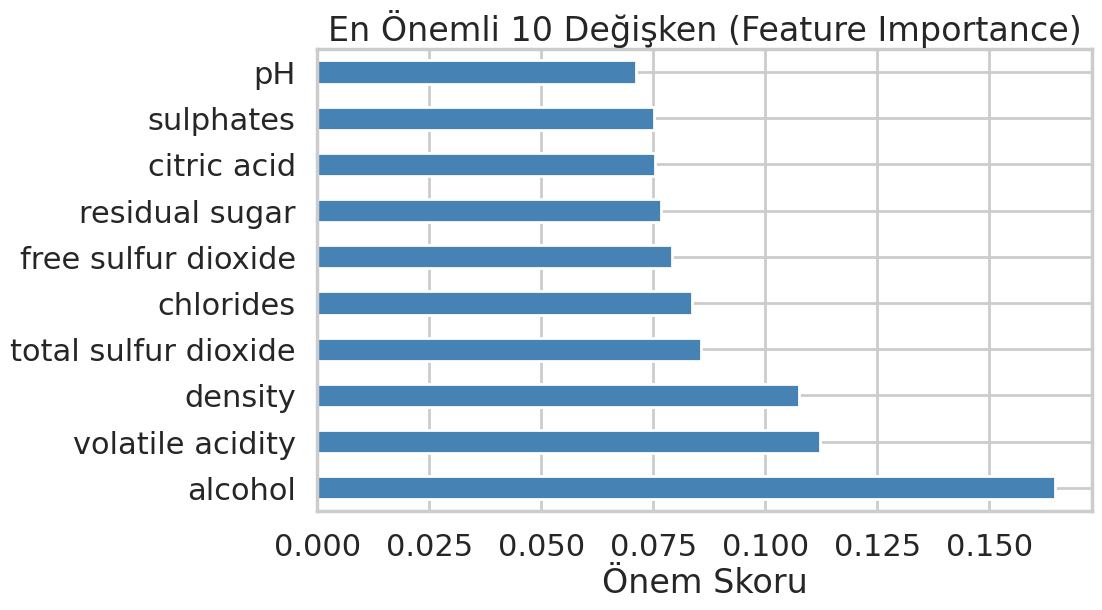

In [67]:
# Önem skorlarını alıyoruz
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# En önemli 10 değişkeni büyükten küçüğe sıralayıp çizdirelim
plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).plot(kind='barh', color='steelblue')
plt.title("En Önemli 10 Değişken (Feature Importance)")
plt.xlabel("Önem Skoru")
plt.show()

Bu sonuçlara korelasyon matrisimizden de aşağı yukarı ulaşabiliyorduk.

confusion matrix çizeceğiz, işlemlerimiz nasıl etki etti bakacağız

In [68]:
from sklearn.metrics import confusion_matrix

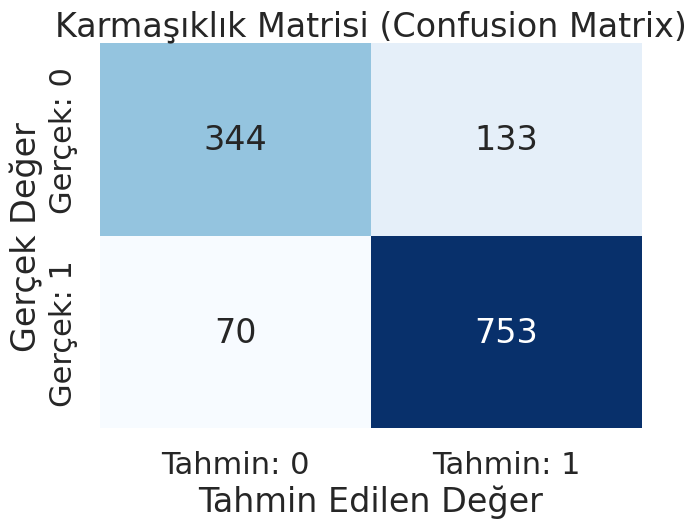

In [69]:
cm = confusion_matrix(y_test, y_pred)

# Isı haritası (Heatmap) ile görselleştirme
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Tahmin: 0', 'Tahmin: 1'],
            yticklabels=['Gerçek: 0', 'Gerçek: 1'])

plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin Edilen Değer')
plt.show()

Önceki karmaşıklık matrisine göre daha olumlu sonuçlar aldığımızı görüyoruz. Random Forest ve class weight=balanced işlemleri tahmin oranımızı gayet yükseltti

SVM atsak ne olur acaba?

In [70]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score

# StandardScaler ve SVM'i pipelineda birleştiriyoruz
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1.0, random_state=42)
)

# Modeli eğitme
svm_model.fit(X_train, y_train)

# Tahmin ve değerlendirme
y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Sınıflandırma Raporu:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7730769230769231

SVM Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.74      0.59      0.66       477
           1       0.79      0.88      0.83       823

    accuracy                           0.77      1300
   macro avg       0.76      0.74      0.74      1300
weighted avg       0.77      0.77      0.77      1300



SVM Random Forest(RF)'tan kötü sonuç verdi peki
##**NEDEN?**

- Aldığımız şarap kalitesi verisi tablo verisidir. Bu durumdaki veriler RF ile daha iyi sonuç veriyor
- Kritik eşik değerlerinin varlığı da bize en optimal model olarak RF'i gösteriyor. SVM daha esnek sınırlar çizeceği için daha çok yanılacaktır.
- RF kullanmak özeten daha mantıklıdır